In [1]:
# Common imports for the Cordoba project
import numpy as np
import matplotlib.pyplot as plt
import ee
ee.Initialize()

from typing import Dict, List, Tuple
# Import the CordobaDataPreprocessor module
from cordobaDataPreprocessor import *
# Import the CordobaPredictor module
from cordobaPredictor import *

In [2]:
def process(roi: ee.Geometry, days: List[str], gee_account: str, gee_credentials_path: str, 
            range_days: int, threshold_denoising: float, threshold_indices: Dict[str, float], 
            clip_roi: bool = True) -> Tuple[ee.Geometry, np.ndarray, np.ndarray]:
    
    """
    Process the deforestation prediction with dynamic ROI and date range.
    :param roi: The area of interest as an ee.Geometry object
    :param days: List of two dates [start_date, end_date]
    """
    # Create a preprocessor instance
    preprocessor = CordobaDataPreprocessor(gee_account, gee_credentials_path)

    # Convert the input roi to a LongLatBBox
    area_of_interest = LongLatBBox.from_ee_geometry(roi)

    # Get the satellite images using sentinel-2 data
    preprocessor.nb_max_step_search = 1
    preprocessor.step_search_image = range_days
    preprocessor.data_source = CordobaDataSource.SENTINEL2
    images = preprocessor.get_satellite_data(days, area_of_interest)
    
    rgb_image_t1 = images[0].get_bands_as_vectors(['red', 'green', 'blue'])
    rgb_image_t2 = images[1].get_bands_as_vectors(['red', 'green', 'blue'])

    # Create a predictor instance
    predictor = CordobaPredictor()

    # Predict the deforestation using dynamic world only with a denoising
    deforest_mask = predictor.predict_CVA(images=images, target_class="trees", 
                                          threshold_change=threshold_indices,
                                          threshold_mask=threshold_denoising)

    # Convert the binary mask to ee.Geometry
    if clip_roi:
        deforest_rois = predictor.get_ee_geometry_from_mask(images[1], deforest_mask, roi)
    else:
        deforest_rois = predictor.get_ee_geometry_from_mask(images[1], deforest_mask)

    return deforest_rois, rgb_image_t1, rgb_image_t2

In [3]:
def get_bbox_from_roi(roi):
    """
    Calcula el bounding box del ROI en coordenadas geográficas.
    """
    # Extraer las coordenadas del ROI
    roi_coords = np.array(roi.getInfo()["coordinates"][0])
    
    # Calcular el bounding box (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min = np.min(roi_coords, axis=0)
    lon_max, lat_max = np.max(roi_coords, axis=0)
    
    return [lon_min, lat_min, lon_max, lat_max]

def geo_to_image_coords(lon, lat, width, height, bbox):
    """
    Convierte coordenadas geográficas (lon, lat) a coordenadas en píxeles dentro de una imagen.
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    
    # Vectorizar las conversiones
    x_pixel = (lon - lon_min) / (lon_max - lon_min) * width
    y_pixel = (1 - (lat - lat_min) / (lat_max - lat_min)) * height
    
    return int(x_pixel), int(y_pixel)

In [12]:
# Login info to GEE
gee_account =  "scigeo@ee-jfloresf17.iam.gserviceaccount.com"
gee_credentials_path = "../../credentials.json"

T1_date = '2022-06-01'
T2_date = '2023-07-01'
range_days = 30
coordinates = [
          [
            [
              -65.608609630863,
              -31.89978610318753
            ],
            [
              -65.61138831755882,
              -31.996241333723177
            ],
            [
              -65.57652842992633,
              -31.99645556588706
            ],
            [
              -65.57425495899388,
              -31.984243533868906
            ],
            [
              -65.56036152551668,
              -31.980601034137393
            ],
            [
              -65.55556197577013,
              -31.971815586967786
            ],
            [
              -65.54571026839622,
              -31.968601188864746
            ],
            [
              -65.53888985559803,
              -31.96217205501017
            ],
            [
              -65.53888985559803,
              -31.949741119823088
            ],
            [
              -65.5573302309401,
              -31.92959085943466
            ],
            [
              -65.608609630863,
              -31.89978610318753
            ]
          ]
        ]

In [15]:
roi = ee.Geometry.Polygon(coordinates)
threshold_denoising = 0.5
days = [T1_date, T2_date]
spectral_indices_threshold = {
    "ndvi": -0.3,
    "ndmi": -0.2,
    "nbr": -0.3,
    "savi": -0.3
}

deforestation_polygon, rgb_image_t1, rgb_image_t2 = process(roi, days, gee_account, gee_credentials_path, 
                                                            range_days, threshold_denoising, 
                                                            spectral_indices_threshold, clip_roi=False)

data source: SENTINEL2
image acquisition...
median composite of 4 images...
mode composite of 4 dynamic world images...
remote preprocessing...
gaussian blur (3, 0.5)...
NDVI...
NDBI...
EVI...
NDMI...
SAVI...
NBR...
converting to CordobaImage...
download...(lo[-65.61138831755882,-65.53888985559803],la[-31.996455565887086,-31.899786103187505])
bands...(['red', 'green', 'blue', 'nir', 'swir', 'ndvi', 'ndbi', 'evi', 'ndmi', 'nbr', 'savi'])
download...(lo[-65.61138831755882,-65.53888985559803],la[-31.996455565887086,-31.899786103187505])
bands...(['water', 'trees', 'grass', 'flooded_vegetation', 'crops', 'shrub_and_scrub', 'built', 'bare', 'snow_and_ice'])
compute mean ndvi...
mean ndvi: 0.44495007005544435
dark object correction...
data source: SENTINEL2
image acquisition...
median composite of 4 images...
mode composite of 4 dynamic world images...
geometric registration...
remote preprocessing...
gaussian blur (3, 0.5)...
NDVI...
NDBI...
EVI...
NDMI...
SAVI...
NBR...
converting to Cordo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4691067562547473].


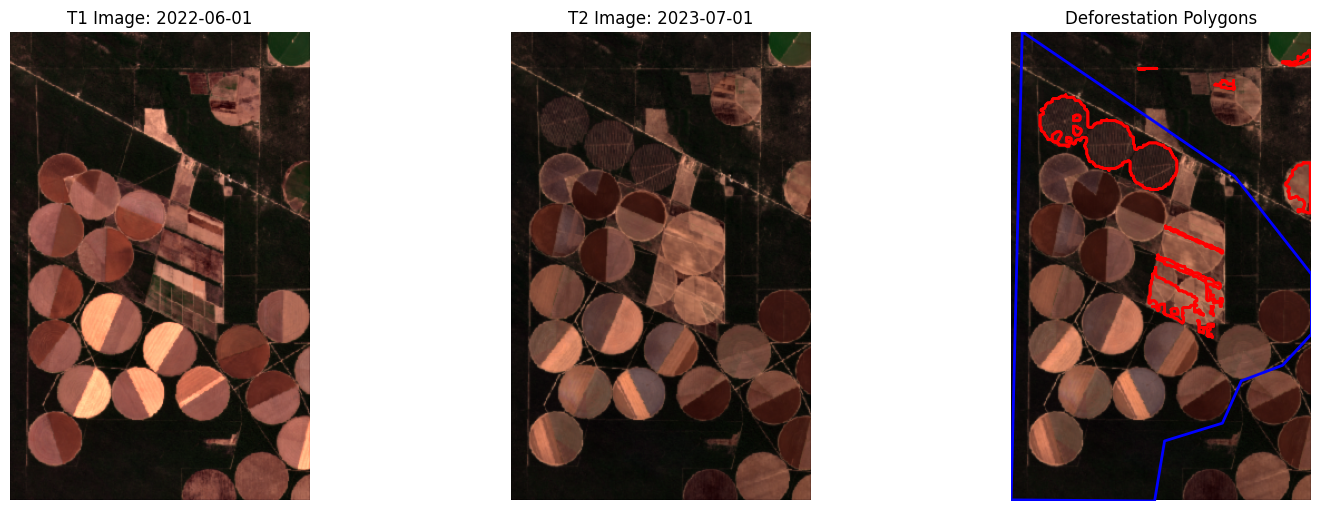

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener bbox del ROI
bbox = get_bbox_from_roi(roi)

# Verificar si el bbox del ROI coincide con la extensión de la imagen
image_width, image_height = rgb_image_t2.shape[1], rgb_image_t2.shape[0]

# Crear la figura con 3 subgráficos del mismo tamaño
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Obtener los límites de los ejes para mantener la igualdad en las dimensiones
xlim, ylim = (0, image_width), (image_height, 0)

# Mostrar rgb_image_t1
axs[0].imshow(rgb_image_t1 * 5 / 10000)  # Normalizar para mostrar correctamente
axs[0].set_title(f"T1 Image: {T1_date}")
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)

# Mostrar rgb_image_t2
axs[1].imshow(rgb_image_t2 * 5 / 10000)  # Normalizar para mostrar correctamente
axs[1].set_title(f"T2 Image: {T2_date}")
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

# Mostrar los polígonos sobre la imagen T2
axs[2].imshow(rgb_image_t2 * 5 / 10000)  # Normalizar para mostrar correctamente
axs[2].set_title("Deforestation Polygons")
axs[2].set_xlim(xlim)
axs[2].set_ylim(ylim)

# Dibujar los polígonos de deforestación de manera independiente
for polygon in deforestation_polygon:
    # Obtener las coordenadas del polígono
    pol_coords = polygon["coordinates"][0]
    
    # Convertir todas las coordenadas a píxeles de manera eficiente
    img_coords = [geo_to_image_coords(lon, lat, image_width, image_height, bbox) for lon, lat in pol_coords]

    # Cerrar el polígono
    img_coords.append(img_coords[0])  # Volver al primer punto
    axs[2].plot(*zip(*img_coords), color='red', linewidth=2)  # Dibujar el polígono

# Dibujar el ROI en azul
roi_coords = np.array(roi.getInfo()["coordinates"][0])
image_roi_coords = [geo_to_image_coords(lon, lat, image_width, image_height, bbox) for lon, lat in roi_coords]
image_roi_coords.append(image_roi_coords[0])
axs[2].plot(*zip(*image_roi_coords), color='blue', linewidth=2)

# Ajustar el layout y eliminar ejes
for ax in axs:
    ax.axis('off')

plt.show()


In [7]:
## Export the deforestation polygons to a geojon file
import geopandas as gpd

# Preprocesar los polígonos de deforestación (evitar getInfo() repetido)
polygons_coords = [polygon.getInfo()["coordinates"][0] for polygon in deforestation_polygon]

# Crear un GeoDataFrame con los polígonos de deforestación
gdf = gpd.GeoDataFrame(geometry=[Polygon(coords) for coords in polygons_coords], crs="EPSG:4326")

# Exportar el GeoDataFrame a un archivo GeoJSON
gdf.to_file("deforestation_polygons.geojson", driver='GeoJSON')